# Analisis Dampak Diskon terhadap Profit Margin (Central - Furniture)

## Metodologi

1. Memfilter data untuk sub-category Furniture yang merugi di region Central.
2. Menghitung `profit_margin` untuk masing-masing tingkat diskon per sub-category.
3. Memvisualisasikan hasil perhitungan.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('superstore.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], yearfirst=True, errors='coerce')

## Filter Data Sub-Category Furniture yang Merugi di Region Central

Memfilter data untuk sub-category Furniture yang merugi (Bookcases, Tables, Furnishings) di region Central sebagai fokus analisis.

In [2]:
filters = (df['region'] == 'Central') & (df['category'] == 'Furniture') & (df['sub_category'] != 'Chairs')
df_central_furniture_loss = df[filters].copy()

## Hitung Profit Margin per Tingkat Diskon

Mengelompokkan data (`df_central_furniture_loss`) berdasarkan sub-category dan diskon untuk menghitung `profit_margin`.

In [3]:
# Menghitung total sales dan profit untuk masing-masing tingkat diskon per sub-category
df_agg = df_central_furniture_loss.groupby(['sub_category', 'discount']).agg(sales=('sales', 'sum'), profit=('profit', 'sum'))

# Menghitung profit margin
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

sales     profit  profit_margin
sub_category discount                                      
Bookcases    0.00       5381.0200   949.1060      17.638031
             0.30       4282.6980  -555.8726     -12.979496
             0.32      14493.4588 -2391.1377     -16.498047
Furnishings  0.00       8609.6700  2038.4384      23.676150
             0.60       6644.7000 -5944.6552     -89.464614
Tables       0.00      16843.6400  2966.7709      17.613597
             0.30      15760.6610 -2216.6766     -14.064617
             0.50       6550.6700 -4309.7447     -65.790899

## Visualisasi Profit Margin per Tingkat Diskon

Memvisualisasikan hasil perhitungan dalam bentuk bar chart untuk mengidentifikasi dampak diskon terhadap profit margin.

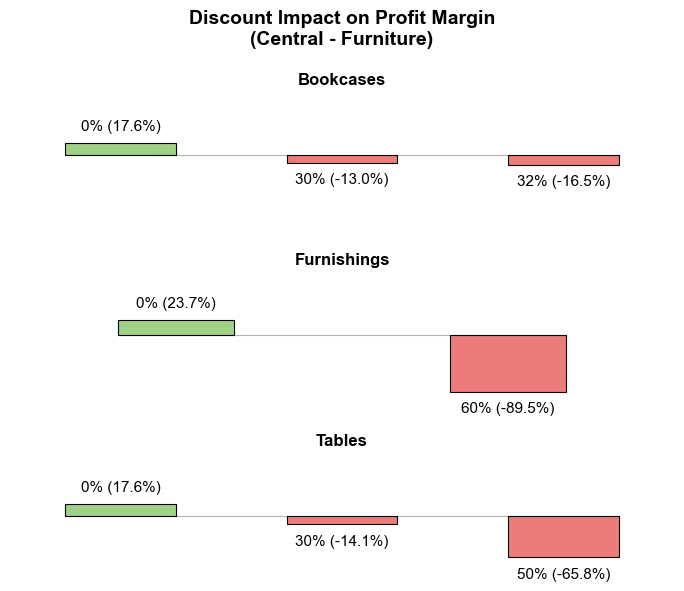

In [4]:
sns.set_theme(style='white')
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 6))
df_agg.reset_index(inplace=True)
sub_category = df_agg['sub_category'].unique().tolist()

suptitle_dict = {'size':14,
                 'weight':'bold',
                 'color':'black',
                 'rotation':0,
                 'alpha':1,
                 'family':plt.rcParams['font.family']}

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':5,
              'alpha':1,
              'family':plt.rcParams['font.family']}

for i in range(len(ax)):
    df_plot = df_agg[df_agg['sub_category'] == sub_category[i]].sort_values(by='profit_margin', ascending=False).copy()
    palette = ['#9ADE7B' if margin > 0 else '#FF6868' for margin in df_plot['profit_margin']]
    sns.barplot(data=df_plot, x='discount', y='profit_margin', ax=ax[i], palette=palette, ec='black', ls='-', lw=0.8)
    
    for bar in ax[i].patches:
        if len(df_plot) == 3:
            bar.set_width(0.5)
            bar.set_xy((bar.get_xy()[0] + 0.15, 0))
        else:
            bar.set_width(0.35)
            bar.set_xy((bar.get_xy()[0] + 0.225, 0))
    
    ax[i].set_title(sub_category[i], **title_dict)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    
    container = ax[i].containers[0]
    labels = [f'{discount*100:.0f}% ({margin:.1f}%)' for discount, margin in zip(df_plot['discount'], df_plot['profit_margin'])]
    ax[i].bar_label(container=container, labels=labels, size=11, weight='normal', color='black', padding=7)
    
    ax[i].set_ylim(-100, 100)
    ax[i].set_xticks(ticks=[])
    ax[i].set_yticks(ticks=[])
    
    if len(df_plot) == 3:
        ax[i].axhline(y=0, xmin=0.083, xmax=0.917, color='black', ls='-', lw=0.8, alpha=0.3)
    else:
        ax[i].axhline(y=0, xmin=0.162, xmax=0.838, color='black', ls='-', lw=0.8, alpha=0.3)
    
    sns.despine(left=True, bottom=True, ax=ax[i])

plt.suptitle('Discount Impact on Profit Margin\n(Central - Furniture)', **suptitle_dict)
plt.tight_layout()
plt.show()